### Setup & Data Loading

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

In [2]:
dataset = pd.read_parquet("../data/processed/cleaned_dataset.parquet")
df = pd.DataFrame(dataset)
df.head()

,id,year,title,abstract,category,period
0,0704.1274,2007,parametric learning and monte carlo optimization,"[uncovers, explores, close, relationship, mont...",cs.lg,2005-2009
1,0704.2010,2007,a study of structural properties on profiles hmms,"[motivation, profile, hidden, markov, model, p...",cs.ai,2005-2009
2,0704.3433,2007,bayesian approach to rough set,"[proposes, approach, training, rough, model, b...",cs.ai,2005-2009
3,0704.3515,2007,comparing robustness of pairwise and multiclas...,"[noise, corruption, variation, face, image, se...",cs.ai,2005-2009
4,0704.3708,2007,network statistics on early english syntax: st...,"[includes, reflection, role, network, english,...",cs.cl,2005-2009


In [3]:
df['abstract'][0]

array(['uncovers', 'explores', 'close', 'relationship', 'monte', 'carlo',
       'optimization', 'parametrized', 'integral', 'mco', 'parametric',
       'machine', 'learning', 'blackbox', 'oracle', 'optimization',
       'make', 'four', 'contribution', 'prove', 'mco', 'mathematically',
       'identical', 'broad', 'class', 'problem', 'identity',
       'potentially', 'provides', 'application', 'domain', 'broadly',
       'applicable', 'technique', 'mco', 'second', 'introduce',
       'immediate', 'sampling', 'version', 'probability', 'collective',
       'algorithm', 'blackbox', 'optimization', 'immediate', 'sampling',
       'transforms', 'original', 'mco', 'accordingly', 'combining',
       'contribution', 'apply', 'technique', 'third', 'contribution',
       'validate', 'improving', 'demonstrating', 'cross', 'validation',
       'bagging', 'improve', 'immediate', 'sampling', 'finally',
       'conventional', 'mco', 'procedure', 'ignore', 'relationship',
       'sample', 'point', 'lo

In [4]:
print(df.shape)

(24806, 6)


In [5]:
# Add this after Cell 5 (the cleaning cell)
# Your parquet already has cleaned data so this is just 
# creating the analysis window

df_analysis = df[df['year'].between(2006, 2022)].copy()
df_analysis = df_analysis.reset_index(drop=True)

print(f"Analysis window: {len(df_analysis)} papers")
print(df_analysis['year'].value_counts().sort_index())

Analysis window: 24375 papers
year
2006      61
2007      68
2008      96
2009     134
2010     237
2011     449
2012     481
2013    1061
2014     707
2015     875
2016    1403
2017    2208
2018    2512
2019    2539
2020    4079
2021    7465
Name: count, dtype: int64


### TF-IDF + PCA Representation

In [6]:
df = df.dropna(subset=["abstract"])

df["abstract"] = df["abstract"].astype(str)

# Optional: remove very short abstracts
df = df[df["abstract"].str.split().str.len() > 20]

In [7]:
tfidf = TfidfVectorizer(
    max_features=5000,      # keep manageable
    stop_words="english",
    ngram_range=(1, 2)      # unigrams + bigrams
)

X_tfidf = tfidf.fit_transform(df["abstract"])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (24806, 5000)


In [8]:
tfidf

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.

In [9]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])

['abbreviation' 'abductive' 'ability' 'ability learn' 'ability model'
 'ablation' 'able' 'able achieve' 'able learn' 'absa' 'absence' 'absolute'
 'absolute improvement' 'abstract' 'abstraction' 'abstractive'
 'abstractive summarization' 'abundant' 'abusive' 'academic']


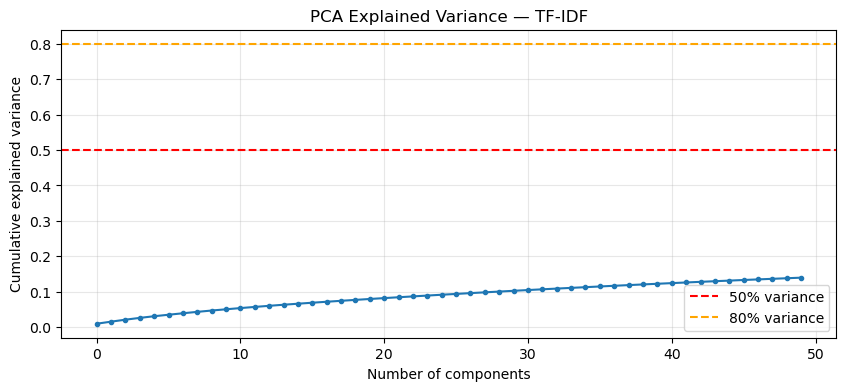

Components for 50% variance: Not reached within 50 components (max=0.140)
Components for 80% variance: Not reached within 50 components (max=0.140)
Variance captured by 50 components: 0.140


In [10]:
# First check how many components explain variance
pca_full = PCA(n_components=50)
tfidf_dense = X_tfidf.toarray()
pca_full.fit(tfidf_dense)

# Plot explained variance
plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', markersize=3)
plt.axhline(y=0.5, color='red', linestyle='--', label='50% variance')
plt.axhline(y=0.8, color='orange', linestyle='--', label='80% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance — TF-IDF')
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig("outputs/figures/pca_tfidf_explained_variance.png", dpi=150)
plt.show()


cumvar = np.cumsum(pca_full.explained_variance_ratio_)

def components_for_threshold(cumvar, threshold):
    indices = np.where(cumvar >= threshold)[0]
    if len(indices) == 0:
        return f"Not reached within {len(cumvar)} components (max={cumvar[-1]:.3f})"
    return indices[0] + 1

print(f"Components for 50% variance: {components_for_threshold(cumvar, 0.5)}")
print(f"Components for 80% variance: {components_for_threshold(cumvar, 0.8)}")
print(f"Variance captured by 50 components: {cumvar[-1]:.3f}")


In [11]:
# Check what words load most strongly on PC1
feature_names = tfidf.get_feature_names_out()
pc1_loadings = pca_full.components_[0]
pc2_loadings = pca_full.components_[1]

# Top words driving PC1
top_pc1 = pd.Series(pc1_loadings, index=feature_names).nlargest(15)
top_pc2 = pd.Series(pc2_loadings, index=feature_names).nlargest(15)

print("Top words on PC1:")
print(top_pc1)
print("\nTop words on PC2:")
print(top_pc2)

Top words on PC1:
language               0.352241
word                   0.240393
translation            0.237138
model                  0.193361
sentence               0.159996
text                   0.139826
task                   0.138773
english                0.119693
corpus                 0.112783
machine translation    0.102695
language model         0.100697
embeddings             0.090536
trained                0.087419
pre                    0.086735
multilingual           0.085437
dtype: float64

Top words on PC2:
translation            0.402609
language               0.181756
machine translation    0.166322
agent                  0.150040
nmt                    0.140952
machine                0.121304
english                0.112420
algorithm              0.104020
game                   0.089247
policy                 0.085115
neural machine         0.081044
resource               0.079759
parallel               0.067686
action                 0.063287
decision            

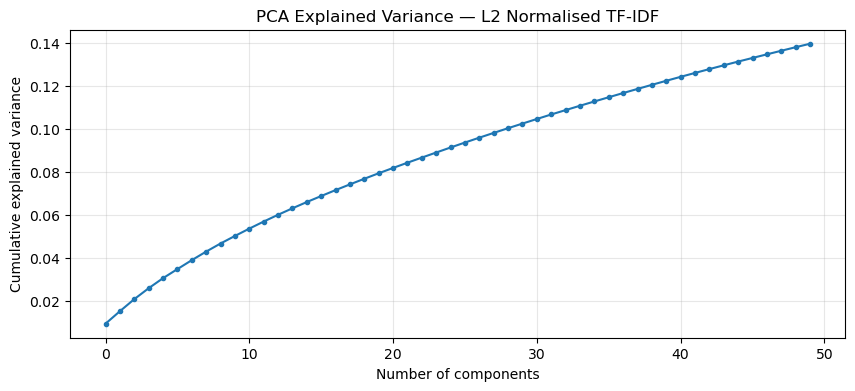

Components for 50% variance: Not reached within 50 components (max=0.140)
Components for 80% variance: Not reached within 50 components (max=0.140)
Variance captured by 50 components: 0.140


In [12]:
from sklearn.preprocessing import normalize

tfidf_normalised = normalize(X_tfidf, norm='l2')
tfidf_dense_norm = tfidf_normalised.toarray()

pca_norm = PCA(n_components=50, random_state=42)
pca_norm.fit(tfidf_dense_norm)

plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca_norm.explained_variance_ratio_), marker='o', markersize=3)
plt.title('PCA Explained Variance — L2 Normalised TF-IDF')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.grid(True, alpha=0.3)
plt.show()

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

def components_for_threshold(cumvar, threshold):
    indices = np.where(cumvar >= threshold)[0]
    if len(indices) == 0:
        return f"Not reached within {len(cumvar)} components (max={cumvar[-1]:.3f})"
    return indices[0] + 1

print(f"Components for 50% variance: {components_for_threshold(cumvar, 0.5)}")
print(f"Components for 80% variance: {components_for_threshold(cumvar, 0.8)}")
print(f"Variance captured by 50 components: {cumvar[-1]:.3f}")


## Insight on PCA

Applying PCA directly to TF-IDF representations highlights a key limitation of linear dimensionality reduction for high-dimensional sparse text data. Across 50 components, the cumulative explained variance reaches only 14%, with no clear elbow in the spectrum, indicating that variance is distributed across many weakly correlated dimensions rather than concentrated in a few dominant directions. This behavior is typical of bag-of-words representations, where documents are described by large vocabularies with limited global structure.

Inspection of the first principal component shows that it primarily captures differences in subfield vocabulary (e.g., cs.CL vs cs.LG), rather than meaningful temporal variation. In this dataset, PCA therefore reflects shifts in category composition more strongly than genuine topic evolution over time. As a result, low-dimensional PCA projections (e.g., 2D visualizations) should be interpreted with caution, as they provide a highly compressed and potentially misleading view of a much richer high-dimensional space.

#### PC1 and PC2 centroid movement over time plots

In [17]:
print(type(df_analysis['abstract'].iloc[0]))

<class 'str'>


In [16]:
df_analysis['abstract'] = df_analysis['abstract'].apply(
    lambda x: " ".join(x) if isinstance(x, (list, np.ndarray)) else str(x)
)

In [18]:
from sklearn.decomposition import PCA

# Refit on df_analysis
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english", 
    ngram_range=(1, 2)
)

X_tfidf_analysis = tfidf.fit_transform(df_analysis['abstract'])
tfidf_dense = X_tfidf_analysis.toarray()

pca_2d = PCA(n_components=2, random_state=42)
coords = pca_2d.fit_transform(tfidf_dense)

df_analysis = df_analysis.copy()
df_analysis['pca_tfidf_x'] = coords[:, 0]
df_analysis['pca_tfidf_y'] = coords[:, 1]

print(f"Variance explained: PC1={pca_2d.explained_variance_ratio_[0]:.3f}, PC2={pca_2d.explained_variance_ratio_[1]:.3f}")
print(f"Columns now: {df_analysis.columns.tolist()}")

Variance explained: PC1=0.010, PC2=0.006
Columns now: ['id', 'year', 'title', 'abstract', 'category', 'period', 'pca_tfidf_x', 'pca_tfidf_y']


/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_82908/3781710816.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', len(years))


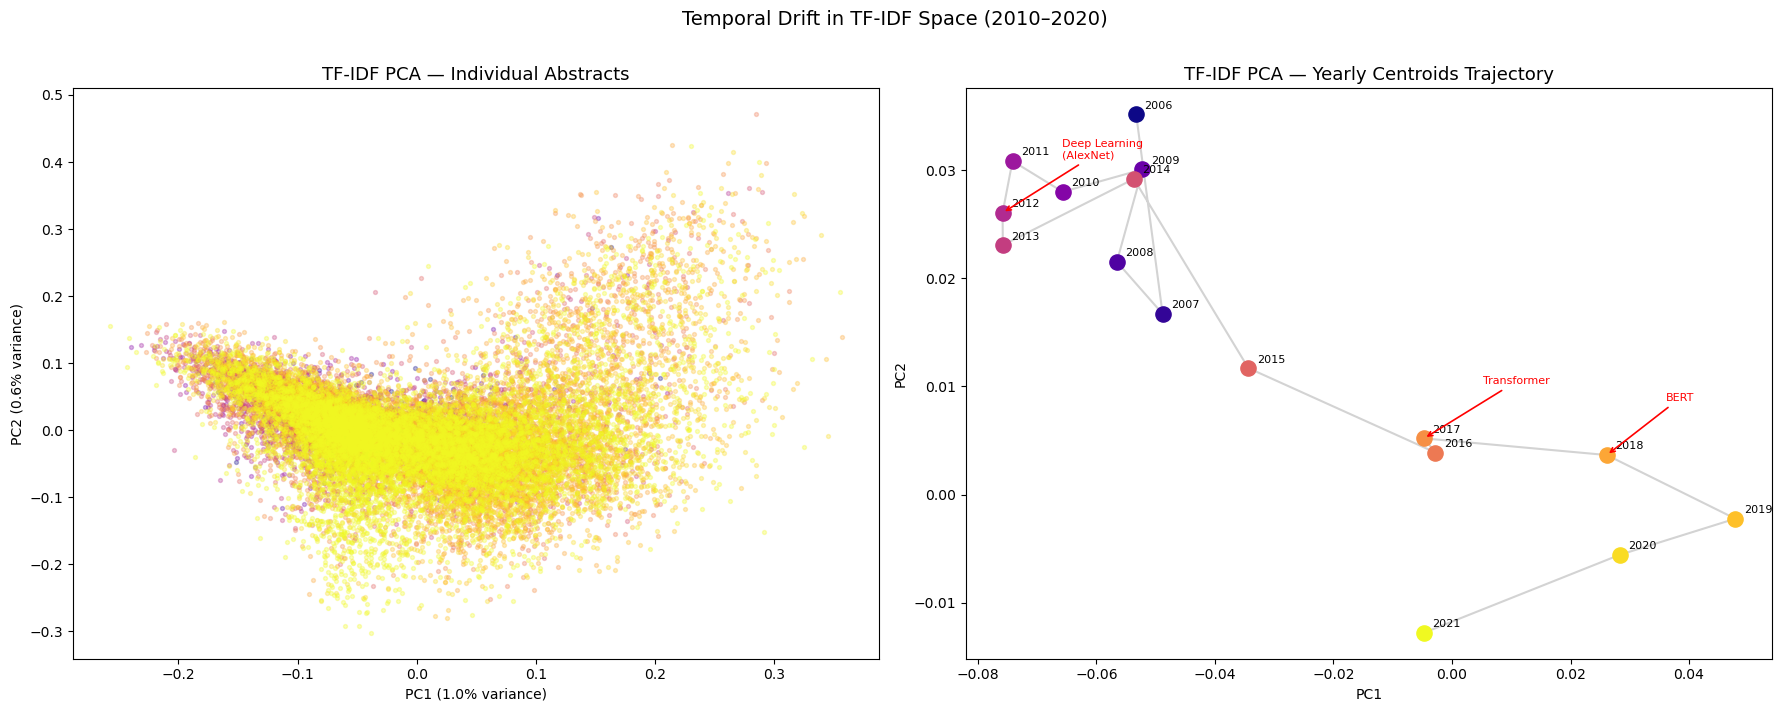

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

years = sorted(df_analysis['year'].unique())
cmap = cm.get_cmap('plasma', len(years))
year_to_color = {year: cmap(i) for i, year in enumerate(years)}

# Plot 1 — individual abstracts coloured by year
ax = axes[0]
for year in years:
    mask = df_analysis['year'] == year
    ax.scatter(
        df_analysis.loc[mask, 'pca_tfidf_x'],
        df_analysis.loc[mask, 'pca_tfidf_y'],
        c=[year_to_color[year]],
        alpha=0.3, s=8, label=str(year)
    )
ax.set_title('TF-IDF PCA — Individual Abstracts', fontsize=13)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')

# Plot 2 — yearly centroids with trajectory line
ax = axes[1]
centroids_tfidf = df_analysis.groupby('year')[['pca_tfidf_x', 'pca_tfidf_y']].mean()

ax.plot(centroids_tfidf['pca_tfidf_x'], centroids_tfidf['pca_tfidf_y'],
        color='lightgray', linewidth=1.5, zorder=1)

for year in years:
    x, y = centroids_tfidf.loc[year]
    color = year_to_color[year]
    ax.scatter(x, y, c=[color], s=120, zorder=2)
    ax.annotate(str(year), (x, y), textcoords="offset points",
                xytext=(6, 4), fontsize=8)

# # Annotate known paradigm shifts
# paradigm_shifts = {2012: 'Deep Learning\n(AlexNet)', 2017: 'Transformer', 2018: 'BERT'}
# for year, label in paradigm_shifts.items():
#     if year in centroids_tfidf.index:
#         x, y = centroids_tfidf.loc[year]
#         ax.annotate(label,
#                     xy=(x, y),
#                     xytext=(x + 0.05, y + 0.05),
#                     fontsize=8, color='red',
#                     arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

# Annotate known paradigm shifts
paradigm_shifts = {
    2012: ('Deep Learning\n(AlexNet)', (-0.07, 0.025)),
    2017: ('Transformer', (-0.01, 0.008)),
    2018: ('BERT', (0.025, 0.004))
}

for year, (label, (x, y)) in paradigm_shifts.items():
    if year in centroids_tfidf.index:
        cx, cy = centroids_tfidf.loc[year]
        ax.annotate(label,
                    xy=(cx, cy),
                    xytext=(cx + 0.01, cy + 0.005),
                    fontsize=8, color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

ax.set_title('TF-IDF PCA — Yearly Centroids Trajectory', fontsize=13)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

plt.suptitle('Temporal Drift in TF-IDF Space (2010–2020)', fontsize=14, y=1.01)
plt.tight_layout()
# plt.savefig("outputs/figures/pca_tfidf_trajectory.png", dpi=150, bbox_inches='tight')
plt.show()

The trajectory shows four distinct phases:

**Phase 1 — 2007 to 2013 (upper left cluster, negative PC1, high PC2)** <br>
Early years cluster tightly together in the upper left, indicating the field had a relatively homogeneous vocabulary during this period. The high PC2 values confirm machine translation vocabulary dominated. The tight clustering suggests this was a stable paradigm period — statistical NLP and ML methods were well established and papers were relatively similar in vocabulary and framing.

**Phase 2 — 2013 to 2016 (downward movement along PC2)** <br>
The trajectory drops sharply downward from 2013 to 2016, moving from high PC2 toward zero. This corresponds exactly to the displacement of statistical MT by neural methods. The field is losing its MT-specific vocabulary signal as neural approaches absorb and replace it. Notably the horizontal PC1 position barely changes during this phase — the field is not yet moving toward the NLP/language axis, it is simply losing its old MT character.

**Phase 3 — 2016 to 2019 (rightward movement along PC1)** <br>
From 2016 the trajectory turns sharply rightward, crossing zero on PC1 and moving into positive territory. This is the transformer and BERT era — NLP vocabulary floods the corpus as language model pretraining becomes the dominant paradigm. The 2017 and 2018 points sit close together before 2019 jumps further right, suggesting BERT's impact accelerated the vocabulary shift rather than causing it suddenly.

**Phase 4 — 2019 to 2021 (downward into negative PC2)** <br>
The trajectory drops steeply downward again after 2019. This likely reflects the rise of RL-based approaches and large language model papers using a new vocabulary that is neither MT-specific nor purely linguistic — terms like reward, agent, prompt, generation pulling PC2 negative.

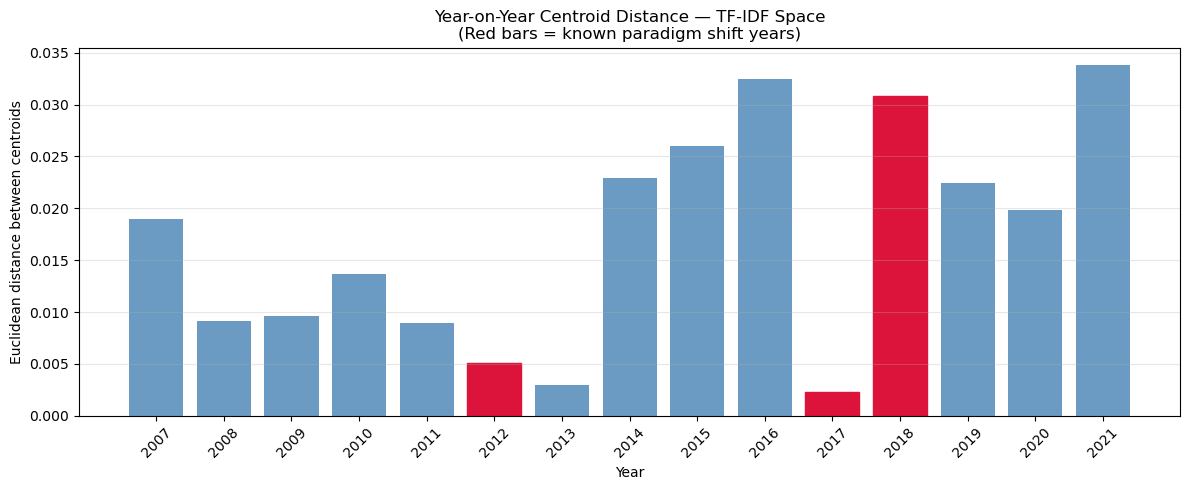


Largest year-on-year shifts:
   year_transition  distance
14       2020-2021  0.033794
9        2015-2016  0.032515
11       2017-2018  0.030874


In [20]:
# Calculate year-on-year centroid movement
centroid_distances = []
for i in range(1, len(years)):
    y1, y2 = years[i-1], years[i]
    c1 = centroids_tfidf.loc[y1].values
    c2 = centroids_tfidf.loc[y2].values
    dist = np.linalg.norm(c2 - c1)
    centroid_distances.append({'year_transition': f"{y1}-{y2}", 'year': y2, 'distance': dist})

dist_df = pd.DataFrame(centroid_distances)

plt.figure(figsize=(12, 5))
bars = plt.bar(dist_df['year'], dist_df['distance'], color='steelblue', alpha=0.8)

# Highlight paradigm shift years
shift_years = [2012, 2017, 2018]
for i, row in dist_df.iterrows():
    if row['year'] in shift_years:
        bars[i].set_color('crimson')
        bars[i].set_alpha(1.0)

plt.xlabel('Year')
plt.ylabel('Euclidean distance between centroids')
plt.title('Year-on-Year Centroid Distance — TF-IDF Space\n(Red bars = known paradigm shift years)')
plt.xticks(dist_df['year'], rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
# plt.savefig("outputs/figures/centroid_distance_tfidf.png", dpi=150)
plt.show()

print("\nLargest year-on-year shifts:")
print(dist_df.nlargest(3, 'distance')[['year_transition', 'distance']])

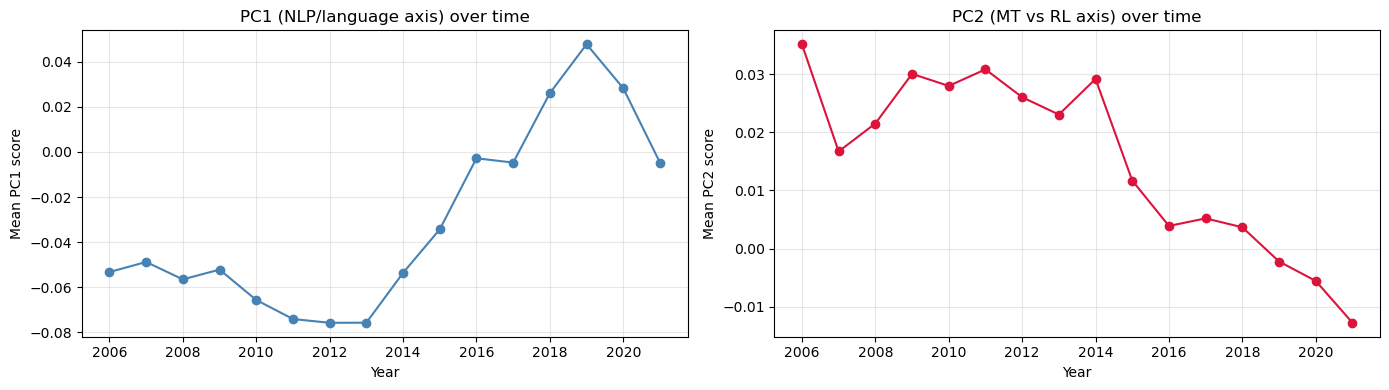

In [21]:
# Check centroid movement along each PC separately
centroids = df_analysis.groupby('year')[['pca_tfidf_x', 'pca_tfidf_y']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# PC1 over time — NLP axis
axes[0].plot(centroids.index, centroids['pca_tfidf_x'], marker='o', color='steelblue')
axes[0].set_title('PC1 (NLP/language axis) over time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean PC1 score')
axes[0].grid(True, alpha=0.3)

# PC2 over time — MT vs RL axis  
axes[1].plot(centroids.index, centroids['pca_tfidf_y'], marker='o', color='crimson')
axes[1].set_title('PC2 (MT vs RL axis) over time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean PC2 score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("outputs/figures/pc1_pc2_over_time.png", dpi=150)
plt.show()

### Analysis
- PC1 increases over time — the corpus is becoming more NLP-vocabulary-heavy, consistent with Thread 1's theory→application finding since NLP is the more applied subfield

### TO-DO: Overall assessment of TF-IDF PCA

In [22]:
# Create cat_combo column from categories
def get_relevant_cats(cat_string):
    relevant = []
    for cat in ['cs.lg', 'cs.cl', 'cs.ai']:
        if cat in str(cat_string):
            relevant.append(cat)
    return '+'.join(sorted(relevant)) if relevant else 'other'

df_analysis = df_analysis.copy()
df_analysis['cat_combo'] = df_analysis['category'].apply(get_relevant_cats)

# Verify it worked
print(df_analysis['cat_combo'].value_counts())

cat_combo
cs.cl    12076
cs.lg     6517
cs.ai     5782
Name: count, dtype: int64


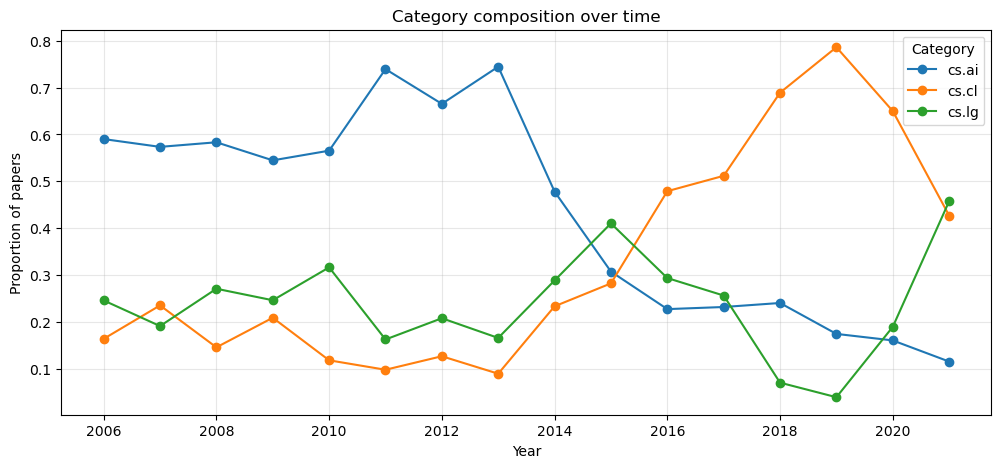

In [23]:
# Does category composition change over time?
cat_by_year = df_analysis.groupby(['year', 'cat_combo']).size().unstack(fill_value=0)
cat_by_year_pct = cat_by_year.div(cat_by_year.sum(axis=1), axis=0)

cat_by_year_pct.plot(figsize=(12, 5), marker='o')
plt.title('Category composition over time')
plt.ylabel('Proportion of papers')
plt.xlabel('Year')
plt.legend(title='Category')
plt.grid(True, alpha=0.3)
# plt.savefig("outputs/figures/category_composition_over_time.png", dpi=150)
plt.show()

_PC1 separates NLP-vocabulary-heavy papers (cs.CL) from algorithm/systems papers (cs.LG, cs.AI). Temporal drift along PC1 therefore reflects both genuine topic evolution and shifts in category composition within the corpus. These two effects cannot be fully disentangled in this representation, which is a limitation of the TF-IDF approach on a multi-category corpus — and one motivation for comparing against sentence embeddings, which capture meaning more independently of surface vocabulary._

/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_82908/2885594158.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', len(years))
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_82908/2885594158.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', len(years))
/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_82908/2885594158.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

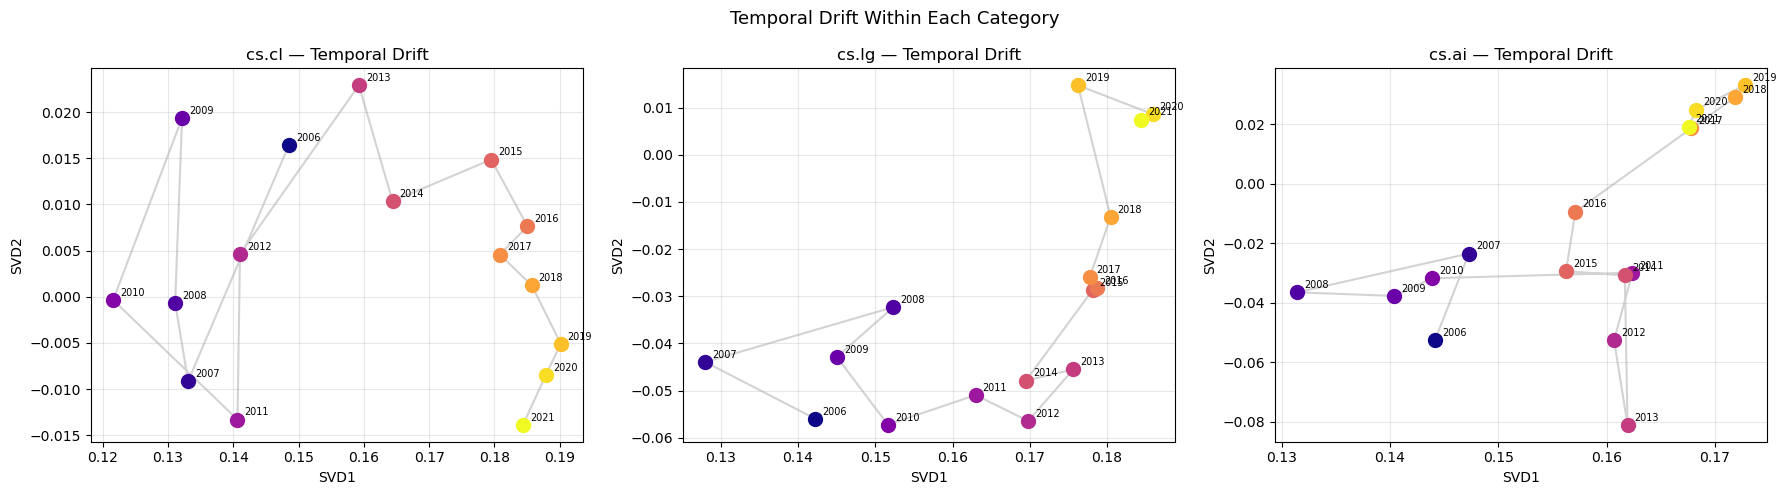

In [24]:
from sklearn.decomposition import TruncatedSVD

results = []

for cat in ['cs.cl', 'cs.lg', 'cs.ai']:
    subset = df_analysis[df_analysis['cat_combo'] == cat].copy()
    
    if len(subset) < 50:
        continue
    
    # Fit TF-IDF on this category only
    tfidf_cat = TfidfVectorizer(
        max_features=5000,
        stop_words="english",
        ngram_range=(1, 2)
    )
    X = tfidf_cat.fit_transform(subset['abstract'])
    
    # TruncatedSVD on this category only
    svd = TruncatedSVD(n_components=2, random_state=42)
    coords = svd.fit_transform(X)
    
    subset['svd_x'] = coords[:, 0]
    subset['svd_y'] = coords[:, 1]
    subset['category'] = cat
    results.append(subset)

df_by_cat = pd.concat(results).reset_index(drop=True)

# Now plot centroids per category — temporal drift within each
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cat in zip(axes, ['cs.cl', 'cs.lg', 'cs.ai']):
    subset = df_by_cat[df_by_cat['category'] == cat]
    centroids = subset.groupby('year')[['svd_x', 'svd_y']].mean()
    
    years = centroids.index.tolist()
    cmap = cm.get_cmap('plasma', len(years))
    
    ax.plot(centroids['svd_x'], centroids['svd_y'],
            color='lightgray', linewidth=1.5, zorder=1)
    
    for i, year in enumerate(years):
        x, y = centroids.loc[year]
        ax.scatter(x, y, c=[cmap(i)], s=100, zorder=2)
        ax.annotate(str(year), (x, y),
                    textcoords="offset points",
                    xytext=(5, 3), fontsize=7)
    
    ax.set_title(f'{cat} — Temporal Drift')
    ax.set_xlabel('SVD1')
    ax.set_ylabel('SVD2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Temporal Drift Within Each Category', fontsize=13)
plt.tight_layout()
# plt.savefig("../outputs/figures/temporal_drift_by_category.png", dpi=150)
plt.show()

In [26]:
# Check what SVD1 and SVD2 capture
feature_names = tfidf.get_feature_names_out()

top_svd1 = pd.Series(svd.components_[0], index=feature_names).nlargest(15)
top_svd2 = pd.Series(svd.components_[1], index=feature_names).nlargest(15)

print("Top words on SVD1:")
print(top_svd1)
print("\nTop words on SVD2:")
print(top_svd2)

Top words on SVD1:
morphological           0.201905
affected                0.174363
look                    0.171974
analogy                 0.171522
model performance       0.135111
art method              0.134082
non monotonic           0.127079
linear programming      0.119425
detailed analysis       0.118034
graph classification    0.107454
term memory             0.101955
popular                 0.101318
incorporating           0.099988
subgraphs               0.099871
series experiment       0.097323
dtype: float64

Top words on SVD2:
affected                0.445066
graph classification    0.329747
look                    0.227697
resolution              0.139872
resolve                 0.137481
exchange                0.136965
incorporating           0.134469
practice                0.121999
scale datasets          0.117960
achieving state         0.092131
term memory             0.078271
post processing         0.077031
diabetes                0.073625
neighboring           

## Build Sentence-BERT embeddings

In [27]:
try:
    from sentence_transformers import SentenceTransformer
    print("sentence-transformers ready")
except ImportError:
    print("Not installed — run the cell below")

sentence-transformers ready


In [28]:
print(f"Papers to encode: {len(df_analysis)}")
print(f"Year range: {df_analysis['year'].min()} - {df_analysis['year'].max()}")
print(f"Sample abstract:\n{df_analysis['abstract'].iloc[0][:200]}")

Papers to encode: 24375
Year range: 2006 - 2021
Sample abstract:
uncovers explores close relationship monte carlo optimization parametrized integral mco parametric machine learning blackbox oracle optimization make four contribution prove mco mathematically identic


In [29]:
from sentence_transformers import SentenceTransformer
import numpy as np
import os

# Path to save
embeddings_path = "../outputs/results/sentence_embeddings.npy"

# Create outputs/results directory if it doesn't exist
os.makedirs("../outputs/results", exist_ok=True)

if os.path.exists(embeddings_path):
    # Load if already generated
    X_embed = np.load(embeddings_path)
    print(f"Loaded from disk: {X_embed.shape}")
else:
    print("Generating embeddings — this will take 5-10 minutes...")
    
    # Load model
    model = SentenceTransformer('all-MiniLM-L6-v2')
    # all-MiniLM-L6-v2 is a good balance:
    # - fast enough for ~18k abstracts on CPU
    # - 384 dimensions
    # - strong semantic quality
    
    # Generate
    X_embed = model.encode(
        df_analysis['abstract'].tolist(),
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    
    # Save immediately
    np.save(embeddings_path, X_embed)
    print(f"Done — saved to {embeddings_path}")
    print(f"Shape: {X_embed.shape}")

Generating embeddings — this will take 5-10 minutes...


Batches:   0%|          | 0/381 [00:00<?, ?it/s]

Done — saved to ../outputs/results/sentence_embeddings.npy
Shape: (24375, 384)


In [30]:
print(f"Embeddings shape: {X_embed.shape}")
print(f"df_analysis shape: {df_analysis.shape}")
print(f"Aligned: {X_embed.shape[0] == len(df_analysis)}")

# Each row in X_embed corresponds to same row in df_analysis
# Verify with a quick spot check
print(f"\nSpot check:")
print(f"Abstract 0 (year {df_analysis['year'].iloc[0]}): {df_analysis['abstract'].iloc[0][:100]}")
print(f"Embedding 0 — first 5 values: {X_embed[0][:5]}")
print(f"Embedding norm (should be ~1.0): {np.linalg.norm(X_embed[0]):.3f}")

Embeddings shape: (24375, 384)
df_analysis shape: (24375, 9)
Aligned: True

Spot check:
Abstract 0 (year 2007): uncovers explores close relationship monte carlo optimization parametrized integral mco parametric m
Embedding 0 — first 5 values: [-0.06361966  0.01712494 -0.02728658  0.01700701  0.02322467]
Embedding norm (should be ~1.0): 1.000


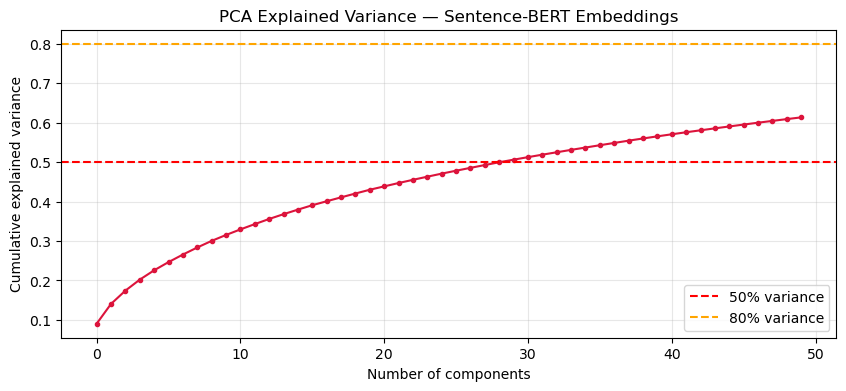

Components for 50% variance: 30
Components for 80% variance: Not reached within 50 components (max=0.613)
Variance in top 2 components: 0.140


In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Explained variance check ──────────────────────────────────────
pca_emb_full = PCA(n_components=50, random_state=42)
pca_emb_full.fit(X_embed)

cumvar_emb = np.cumsum(pca_emb_full.explained_variance_ratio_)

def components_for_threshold(cumvar, threshold):
    indices = np.where(cumvar >= threshold)[0]
    if len(indices) == 0:
        return f"Not reached within {len(cumvar)} components (max={cumvar[-1]:.3f})"
    return indices[0] + 1

plt.figure(figsize=(10, 4))
plt.plot(cumvar_emb, marker='o', markersize=3, color='crimson')
plt.axhline(y=0.5, color='red', linestyle='--', label='50% variance')
plt.axhline(y=0.8, color='orange', linestyle='--', label='80% variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance — Sentence-BERT Embeddings')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("../outputs/figures/pca_embeddings_explained_variance.png", dpi=150)
plt.show()

print(f"Components for 50% variance: {components_for_threshold(cumvar_emb, 0.5)}")
print(f"Components for 80% variance: {components_for_threshold(cumvar_emb, 0.8)}")
print(f"Variance in top 2 components: {cumvar_emb[1]:.3f}")

In [32]:
# ── 2D PCA reduction ─────────────────────────────────────────────
pca_emb_2d = PCA(n_components=2, random_state=42)
emb_2d = pca_emb_2d.fit_transform(X_embed)

df_analysis = df_analysis.copy()
df_analysis['pca_emb_x'] = emb_2d[:, 0]
df_analysis['pca_emb_y'] = emb_2d[:, 1]

print(f"PC1: {pca_emb_2d.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca_emb_2d.explained_variance_ratio_[1]:.3f}")
print(f"Total 2D: {sum(pca_emb_2d.explained_variance_ratio_):.3f}")

# ── What do embedding PCs capture? ───────────────────────────────
# Unlike TF-IDF we can't inspect word loadings directly
# Instead look at what abstracts sit at the extremes of each axis
print("\n--- Most positive PC1 abstracts ---")
top_pc1 = df_analysis.nlargest(3, 'pca_emb_x')[['year', 'abstract']]
for _, row in top_pc1.iterrows():
    print(f"\n{row['year']}: {row['abstract'][:200]}")
    print("---")

print("\n--- Most negative PC1 abstracts ---")
bot_pc1 = df_analysis.nsmallest(3, 'pca_emb_x')[['year', 'abstract']]
for _, row in bot_pc1.iterrows():
    print(f"\n{row['year']}: {row['abstract'][:200]}")
    print("---")

PC1: 0.090
PC2: 0.050
Total 2D: 0.140

--- Most positive PC1 abstracts ---

2016: propose bidimensional attention recursive autoencoder battrae integrate clue sourcetarget interaction multiple level granularity bilingual phrase representation employ recursive autoencoders generate 
---

2021: exploration sentence embeddings text text transformer sentence embeddings broadly useful language processing task achieves impressive performance language task cast sequence sequence mapping problem u
---

2021: semantic sentence embeddings usually supervisedly built minimizing distance pair embeddings sentence labelled semantically similar annotator since big labelled datasets rare particular non english lan
---

--- Most negative PC1 abstracts ---

2013: mdps represented compactly dynamic bayesian network although structure value function retain structure process recent value function factored mdps often approximated decomposed value function linear c
---

2014: parameter estimation uncertain re

/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_82908/4233604431.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', len(years))


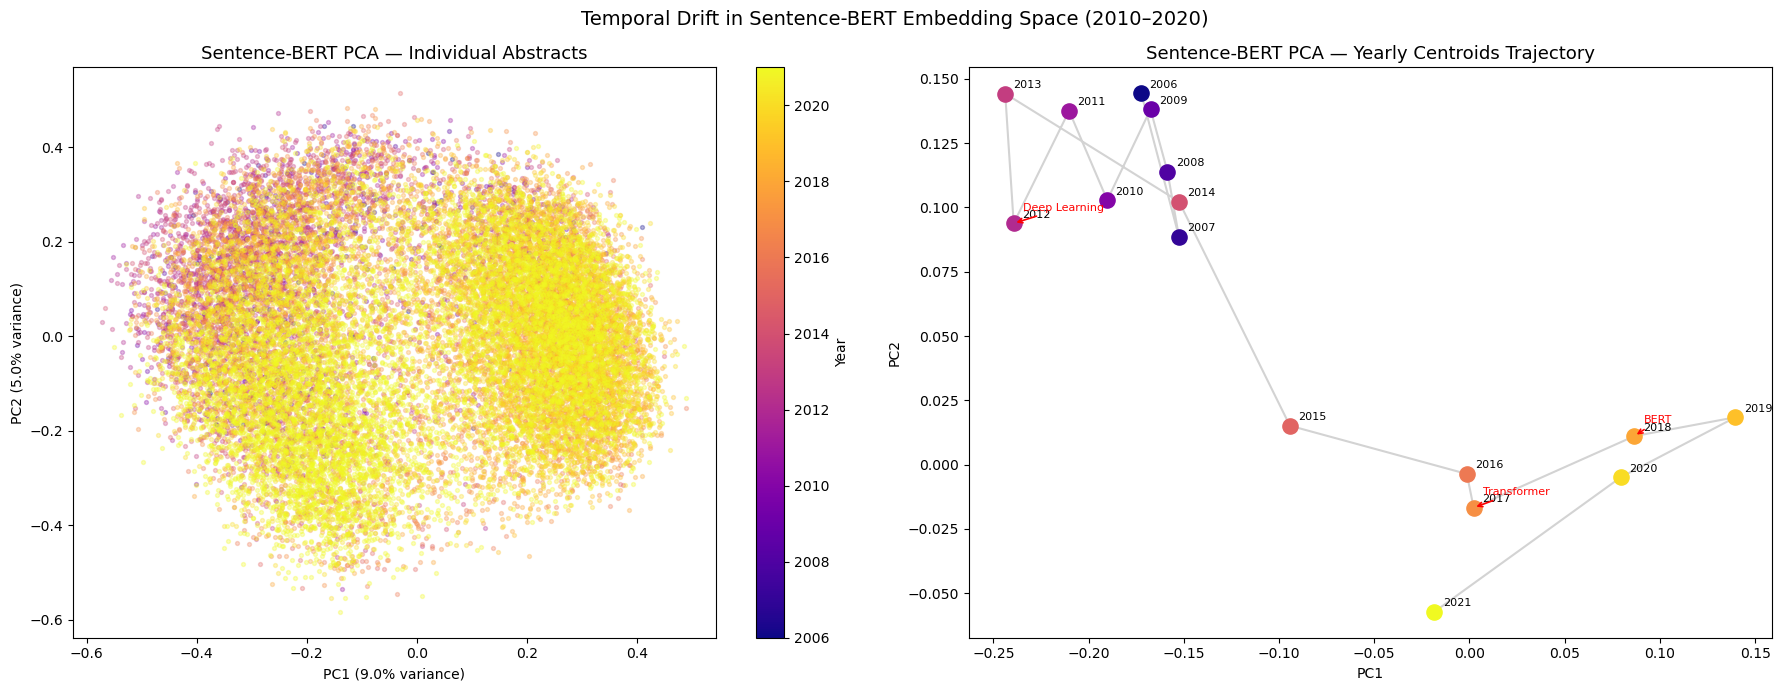

In [34]:
years = sorted(df_analysis['year'].unique())
cmap = cm.get_cmap('plasma', len(years))
year_to_color = {year: cmap(i) for i, year in enumerate(years)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: individual abstracts ────────────────────────────────────
ax = axes[0]
for year in years:
    mask = df_analysis['year'] == year
    ax.scatter(
        df_analysis.loc[mask, 'pca_emb_x'],
        df_analysis.loc[mask, 'pca_emb_y'],
        c=[year_to_color[year]], alpha=0.3, s=8, label=str(year)
    )
ax.set_title('Sentence-BERT PCA — Individual Abstracts', fontsize=13)
ax.set_xlabel(f"PC1 ({pca_emb_2d.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca_emb_2d.explained_variance_ratio_[1]:.1%} variance)")

# Colorbar
sm = plt.cm.ScalarMappable(cmap='plasma',
     norm=plt.Normalize(vmin=min(years), vmax=max(years)))
plt.colorbar(sm, ax=ax, label='Year')

# ── Right: centroid trajectory ────────────────────────────────────
ax = axes[1]
centroids_emb = df_analysis.groupby('year')[['pca_emb_x', 'pca_emb_y']].mean()

ax.plot(centroids_emb['pca_emb_x'], centroids_emb['pca_emb_y'],
        color='lightgray', linewidth=1.5, zorder=1)

for year in years:
    x, y = centroids_emb.loc[year]
    ax.scatter(x, y, c=[year_to_color[year]], s=120, zorder=2)
    ax.annotate(str(year), (x, y),
                textcoords="offset points",
                xytext=(6, 4), fontsize=8)

# Annotate paradigm shifts using actual centroid positions
paradigm_years = {2012: 'Deep Learning', 2017: 'Transformer', 2018: 'BERT'}
for year, label in paradigm_years.items():
    if year in centroids_emb.index:
        x, y = centroids_emb.loc[year]
        ax.annotate(label,
                    xy=(x, y),
                    xytext=(x + 0.005, y + 0.005),
                    fontsize=8, color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

ax.set_title('Sentence-BERT PCA — Yearly Centroids Trajectory', fontsize=13)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

plt.suptitle('Temporal Drift in Sentence-BERT Embedding Space (2010–2020)',
             fontsize=14)
plt.tight_layout()
# plt.savefig("../outputs/figures/pca_embeddings_trajectory.png",
            # dpi=150, bbox_inches='tight')
plt.show()

/Users/musa.official/miniforge3/envs/text_analytics/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


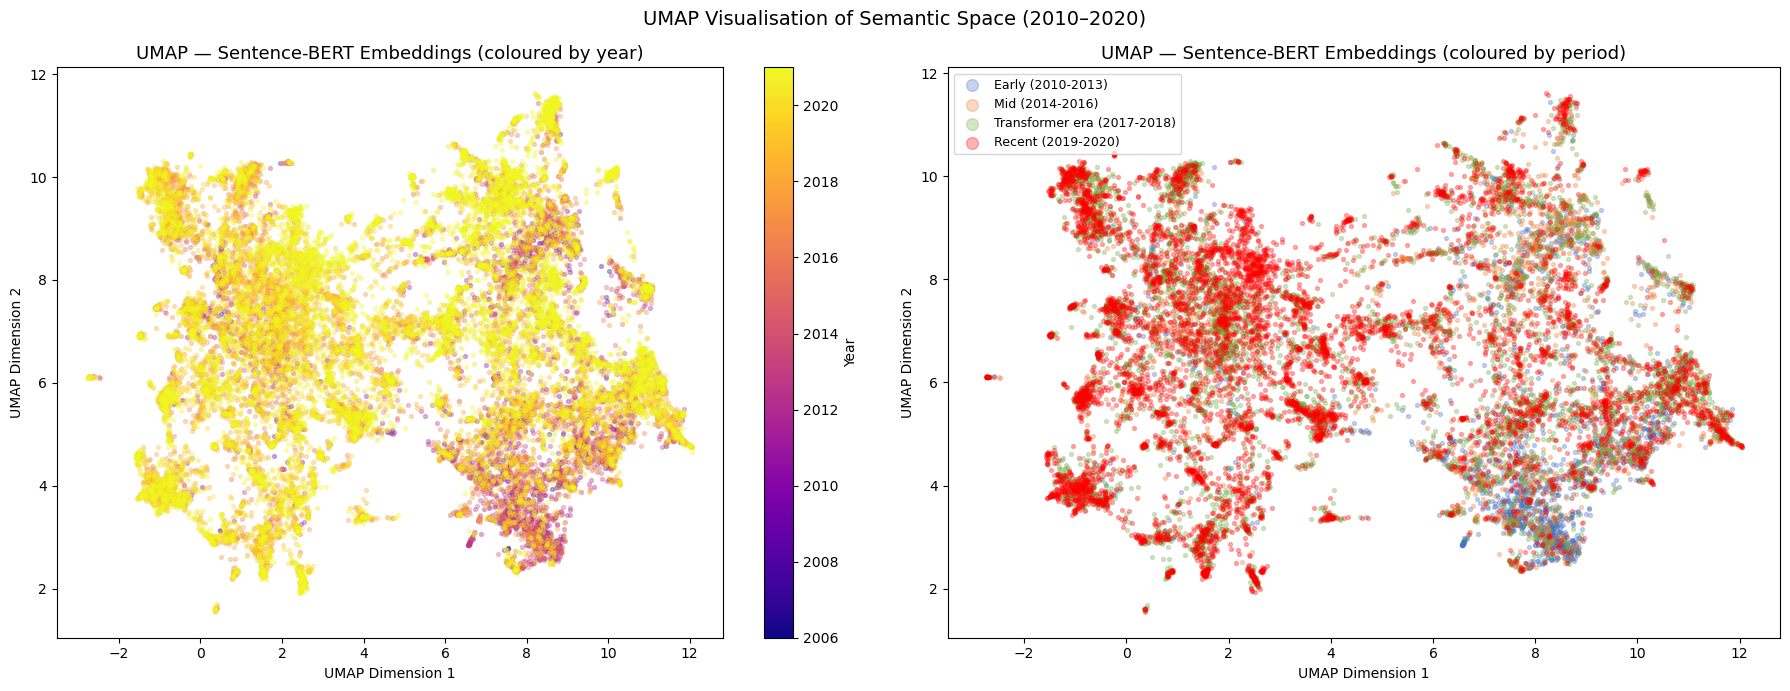

In [36]:
import umap

# ── Fit UMAP ─────────────────────────────────────────────────────
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42,
    metric='cosine'    # cosine is better for embeddings than euclidean
)

umap_2d = reducer.fit_transform(X_embed)

df_analysis['umap_x'] = umap_2d[:, 0]
df_analysis['umap_y'] = umap_2d[:, 1]

# ── Plot coloured by year ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left — coloured by year
ax = axes[0]
for year in years:
    mask = df_analysis['year'] == year
    ax.scatter(
        df_analysis.loc[mask, 'umap_x'],
        df_analysis.loc[mask, 'umap_y'],
        c=[year_to_color[year]], alpha=0.3, s=8
    )
ax.set_title('UMAP — Sentence-BERT Embeddings (coloured by year)',
             fontsize=13)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
sm = plt.cm.ScalarMappable(cmap='plasma',
     norm=plt.Normalize(vmin=min(years), vmax=max(years)))
plt.colorbar(sm, ax=ax, label='Year')

# Right — coloured by period
ax = axes[1]
period_map = {
    2010: 'Early (2010-2013)', 2011: 'Early (2010-2013)',
    2012: 'Early (2010-2013)', 2013: 'Early (2010-2013)',
    2014: 'Mid (2014-2016)',   2015: 'Mid (2014-2016)',
    2016: 'Mid (2014-2016)',
    2017: 'Transformer era (2017-2018)',
    2018: 'Transformer era (2017-2018)',
    2019: 'Recent (2019-2020)',
    2020: 'Recent (2019-2020)'
}
period_colors = {
    'Early (2010-2013)':          '#4472C4',
    'Mid (2014-2016)':            '#ED7D31',
    'Transformer era (2017-2018)':'#70AD47',
    'Recent (2019-2020)':         '#FF0000'
}

df_analysis['period'] = df_analysis['year'].map(period_map)

for period, color in period_colors.items():
    mask = df_analysis['period'] == period
    ax.scatter(
        df_analysis.loc[mask, 'umap_x'],
        df_analysis.loc[mask, 'umap_y'],
        c=color, alpha=0.3, s=8, label=period
    )
ax.set_title('UMAP — Sentence-BERT Embeddings (coloured by period)',
             fontsize=13)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(markerscale=3, fontsize=9)

plt.suptitle('UMAP Visualisation of Semantic Space (2010–2020)',
             fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/umap_embeddings.png",
            dpi=150, bbox_inches='tight')
plt.show()

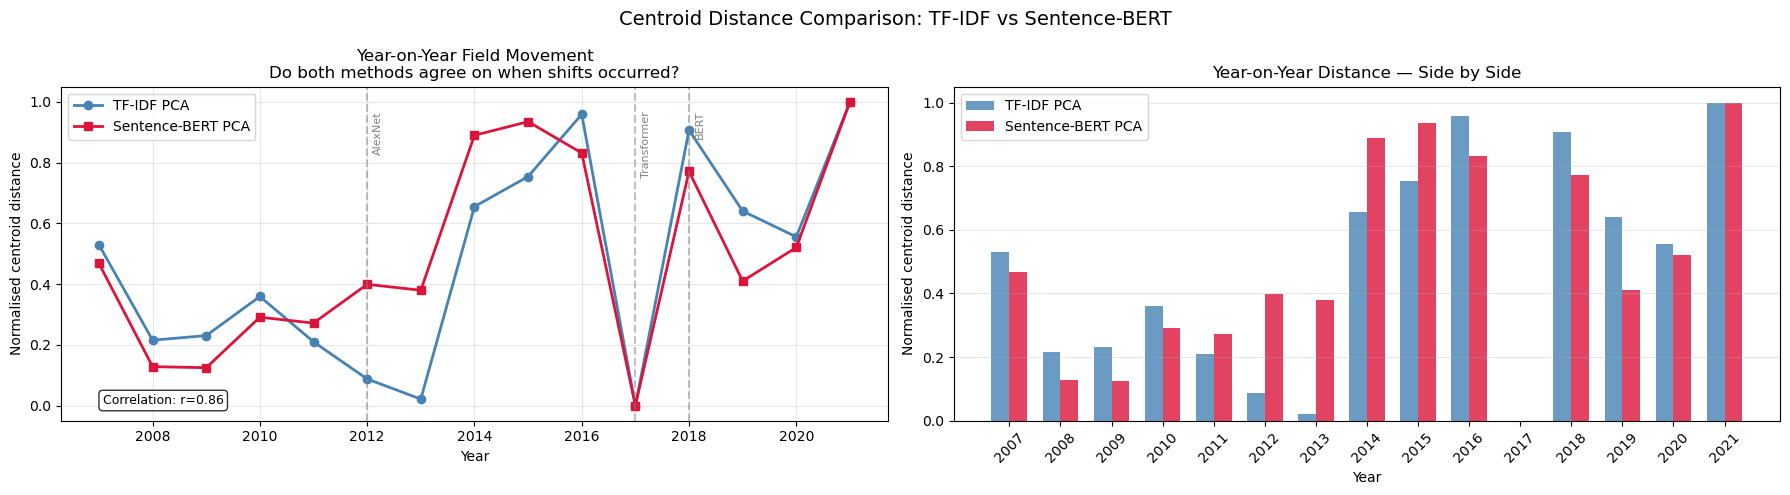


Correlation between methods: r=0.863

Top 3 movement years — TF-IDF:
    year  distance_norm
14  2021       1.000000
9   2016       0.959347
11  2018       0.907228

Top 3 movement years — Embeddings:
    year  distance_norm
14  2021       1.000000
8   2015       0.934976
7   2014       0.889989


In [37]:
from sklearn.preprocessing import MinMaxScaler

# ── Compute distances in embedding PCA space ──────────────────────
centroids_emb = df_analysis.groupby('year')[['pca_emb_x', 'pca_emb_y']].mean()

emb_distances = []
for i in range(1, len(years)):
    y1, y2 = years[i-1], years[i]
    c1 = centroids_emb.loc[y1].values
    c2 = centroids_emb.loc[y2].values
    dist = np.linalg.norm(c2 - c1)
    emb_distances.append({'year': y2, 'distance': dist})

emb_dist_df = pd.DataFrame(emb_distances)

# ── Also recompute TF-IDF centroid distances ──────────────────────
centroids_tfidf = df_analysis.groupby('year')[['pca_tfidf_x', 'pca_tfidf_y']].mean()

tfidf_distances = []
for i in range(1, len(years)):
    y1, y2 = years[i-1], years[i]
    c1 = centroids_tfidf.loc[y1].values
    c2 = centroids_tfidf.loc[y2].values
    dist = np.linalg.norm(c2 - c1)
    tfidf_distances.append({'year': y2, 'distance': dist})

tfidf_dist_df = pd.DataFrame(tfidf_distances)

# ── Normalise both to 0-1 for fair comparison ─────────────────────
scaler = MinMaxScaler()
tfidf_dist_df['distance_norm'] = scaler.fit_transform(
    tfidf_dist_df[['distance']])
emb_dist_df['distance_norm'] = scaler.fit_transform(
    emb_dist_df[['distance']])

# ── Side-by-side comparison plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left — overlaid comparison
ax = axes[0]
ax.plot(tfidf_dist_df['year'], tfidf_dist_df['distance_norm'],
        marker='o', label='TF-IDF PCA', color='steelblue',
        linewidth=2)
ax.plot(emb_dist_df['year'], emb_dist_df['distance_norm'],
        marker='s', label='Sentence-BERT PCA', color='crimson',
        linewidth=2)

for shift_year, label in {2012: 'AlexNet', 2017: 'Transformer',
                           2018: 'BERT'}.items():
    if shift_year in tfidf_dist_df['year'].values:
        ax.axvline(x=shift_year, color='gray',
                   linestyle='--', alpha=0.5)
        ax.text(shift_year + 0.1, 0.97, label,
                fontsize=8, color='gray', va='top', rotation=90)

correlation = np.corrcoef(
    tfidf_dist_df['distance_norm'],
    emb_dist_df['distance_norm']
)[0, 1]

ax.text(0.05, 0.05, f'Correlation: r={correlation:.2f}',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Year')
ax.set_ylabel('Normalised centroid distance')
ax.set_title('Year-on-Year Field Movement\nDo both methods agree on when shifts occurred?')
ax.legend()
ax.grid(True, alpha=0.3)

# Right — raw distances separately
ax = axes[1]
width = 0.35
x = np.arange(len(tfidf_dist_df))
bars1 = ax.bar(x - width/2, tfidf_dist_df['distance_norm'],
               width, label='TF-IDF PCA',
               color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, emb_dist_df['distance_norm'],
               width, label='Sentence-BERT PCA',
               color='crimson', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(tfidf_dist_df['year'], rotation=45)
ax.set_xlabel('Year')
ax.set_ylabel('Normalised centroid distance')
ax.set_title('Year-on-Year Distance — Side by Side')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Centroid Distance Comparison: TF-IDF vs Sentence-BERT',
             fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/centroid_distance_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCorrelation between methods: r={correlation:.3f}")
print(f"\nTop 3 movement years — TF-IDF:")
print(tfidf_dist_df.nlargest(3, 'distance_norm')[['year', 'distance_norm']])
print(f"\nTop 3 movement years — Embeddings:")
print(emb_dist_df.nlargest(3, 'distance_norm')[['year', 'distance_norm']])

In [38]:
# Check if peak movement years correspond to known paradigm shifts
print("=== Robustness Check ===")
print("\nKnown paradigm shift years: 2012 (AlexNet), 2017 (Transformer), 2018 (BERT)")

print("\nTF-IDF — movement rank by year:")
print(tfidf_dist_df.sort_values('distance_norm',
      ascending=False)[['year', 'distance_norm']].to_string())

print("\nEmbeddings — movement rank by year:")
print(emb_dist_df.sort_values('distance_norm',
      ascending=False)[['year', 'distance_norm']].to_string())

# Check specifically if 2012, 2017, 2018 are in top half of movement years
n_years = len(tfidf_dist_df)
shift_years = [2012, 2017, 2018]

for method, dist_df in [('TF-IDF', tfidf_dist_df),
                         ('Embeddings', emb_dist_df)]:
    ranked = dist_df.sort_values('distance_norm',
              ascending=False).reset_index(drop=True)
    ranked['rank'] = ranked.index + 1
    print(f"\n{method} — paradigm shift year ranks:")
    for yr in shift_years:
        row = ranked[ranked['year'] == yr]
        if len(row) > 0:
            rank = row['rank'].values[0]
            pct = rank / n_years * 100
            print(f"  {yr}: rank {rank}/{n_years} "
                  f"(top {pct:.0f}%)")

=== Robustness Check ===

Known paradigm shift years: 2012 (AlexNet), 2017 (Transformer), 2018 (BERT)

TF-IDF — movement rank by year:
    year  distance_norm
14  2021       1.000000
9   2016       0.959347
11  2018       0.907228
8   2015       0.754126
7   2014       0.655331
12  2019       0.640373
13  2020       0.555625
0   2007       0.529324
3   2010       0.359148
2   2009       0.230353
1   2008       0.215284
4   2011       0.209905
5   2012       0.087458
6   2013       0.021176
10  2017       0.000000

Embeddings — movement rank by year:
    year  distance_norm
14  2021       1.000000
8   2015       0.934976
7   2014       0.889989
9   2016       0.831838
11  2018       0.771194
13  2020       0.520648
0   2007       0.467867
12  2019       0.409926
5   2012       0.399150
6   2013       0.379704
3   2010       0.290846
4   2011       0.271659
1   2008       0.128119
2   2009       0.124637
10  2017       0.000000

TF-IDF — paradigm shift year ranks:
  2012: rank 13/15 (top